In [13]:
import pandas as pd
import numpy as np
import re
import io
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from google.colab import files

# Upload file
print("Please upload your dataset (CSV or Excel format):")
uploaded = files.upload()

# Extract filename
file_name = list(uploaded.keys())[0]

# Detect file type and load it into df
if file_name.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
elif file_name.endswith('.xlsx') or file_name.endswith('.xls'):
    df = pd.read_excel(io.BytesIO(uploaded[file_name]))
else:
    print("Error: Please upload a valid .csv or .xlsx file.")

print(f"\nDataset has with {df.shape[0]} rows and {df.shape[1]} columns.\n")

print("Table: f means NOT fraud and t means fraud")
dist_df = df['fraudulent'].value_counts(dropna=False).reset_index()
dist_df.columns = ['Label', 'Count']
display(dist_df)

Please upload your dataset (CSV or Excel format):


Saving DataSet.csv to DataSet (2).csv

Dataset has with 17880 rows and 18 columns.

Table: f means NOT fraud and t means fraud


,Label,Count
0,f,17014
1,t,866


In [14]:
# Remove corrupted rows and missing labels
df_clean = df[df['fraudulent'].isin(['t', 'f'])].copy()
df_clean['is_scam'] = df_clean['fraudulent'].map({'t': 1, 'f': 0})
scam_ratio = df_clean['is_scam'].mean() * 100
print(f"Cleaned dataset size: {len(df_clean)} rows")
print(f"Scam Ratio: {scam_ratio:.2f}% \n")

# Missing values (text)
text_cols = ['title', 'company_profile', 'description', 'requirements']
for col in text_cols:
    df_clean[col] = df_clean[col].fillna('')

# Combine and Normalise Text
df_clean['full_text'] = (df_clean['title'] + " " +
                         df_clean['company_profile'] + " " +
                         df_clean['description'] + " " +
                         df_clean['requirements'])

# Remove whitespace and punctuation
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['processed_text'] = df_clean['full_text'].apply(clean_text)

# Feature importance for company logo
df_clean['has_company_logo'] = df_clean['has_company_logo'].fillna('f').map({'t': 1, 'f': 0})

no_logo_scam_rate = df_clean[df_clean['has_company_logo'] == 0]['is_scam'].mean() * 100
logo_scam_rate = df_clean[df_clean['has_company_logo'] == 1]['is_scam'].mean() * 100

heuristic_df = pd.DataFrame({
    "Company Logo Status": ["Missing", "Present"],
    "Scam Rate (%)": [round(no_logo_scam_rate, 2), round(logo_scam_rate, 2)]
})

print("Company logo scam rate")
display(heuristic_df)

Cleaned dataset size: 17880 rows
Scam Ratio: 4.84% 

Company logo scam rate


,Company Logo Status,Scam Rate (%)
0,Missing,15.93
1,Present,1.99


In [20]:
# Separate features and target variables
X = df_clean['processed_text']
y = df_clean['is_scam']

# Train/test Split with same class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

split_df = pd.DataFrame({
    "Split": ["Training Set", "Test Set"],
    "Row Count": [len(X_train), len(X_test)],
    "Scam Proportion": [f"{y_train.mean()*100:.2f}%", f"{y_test.mean()*100:.2f}%"]
})

display(split_df)

,Split,Row Count,Scam Proportion
0,Training Set,14304,4.84%
1,Test Set,3576,4.84%


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# TF-IDF
print("Vectorising text")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 3))
X_train_text = tfidf.fit_transform(X_train).toarray()
X_test_text = tfidf.transform(X_test).toarray()

# Metadata Features
meta_cols = ['telecommuting', 'has_company_logo', 'has_questions']

# Convert t/f to 1/0, fill missing with 0
for col in meta_cols:
    df_clean[col] = df_clean[col].map({'t': 1, 'f': 0}).fillna(0)

X_train_meta = df_clean.loc[X_train.index, meta_cols].values
X_test_meta = df_clean.loc[X_test.index, meta_cols].values

print(f"Text Input Shape: {X_train_text.shape}")
print(f"Metadata Input Shape: {X_train_meta.shape}")

Vectorising text
Text Input Shape: (14304, 5000)
Metadata Input Shape: (14304, 3)


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights to penalize the model for missing scams
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

# ext Processor
text_input = Input(shape=(X_train_text.shape[1],), name='text_input')
x_text = Dense(128, activation='relu')(text_input)
x_text = Dropout(0.5)(x_text)
x_text = Dense(64, activation='relu')(x_text)

# Metadata Processor
meta_input = Input(shape=(X_train_meta.shape[1],), name='meta_input')
x_meta = Dense(16, activation='relu')(meta_input)

# Merge branches
merged = Concatenate()([x_text, x_meta])
x_combined = Dense(32, activation='relu')(merged)
x_combined = Dropout(0.3)(x_combined)

# Final Output Layer
output = Dense(1, activation='sigmoid', name='output')(x_combined)

# Compile model
model = Model(inputs=[text_input, meta_input], outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='pr_auc', curve='PR')]
)

print("\nTrain the combined model for 3 epochs")
history = model.fit(
    [X_train_text, X_train_meta],
    y_train,
    epochs=3,
    batch_size=32,
    validation_data=([X_test_text, X_test_meta], y_test),
    class_weight=class_weights,
    verbose=1
)


Train the combined model for 3 epochs
Epoch 1/3
447/447 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9142 - loss: 0.3583 - pr_auc: 0.5608 - val_accuracy: 0.9147 - val_loss: 0.2391 - val_pr_auc: 0.8768
Epoch 2/3
447/447 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9559 - loss: 0.1218 - pr_auc: 0.8851 - val_accuracy: 0.9765 - val_loss: 0.0736 - val_pr_auc: 0.8845
Epoch 3/3
447/447 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9722 - loss: 0.0763 - pr_auc: 0.9421 - val_accuracy: 0.9695 - val_loss: 0.0887 - val_pr_auc: 0.8866


112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification (Threshold = 0.75):
                precision    recall  f1-score   support

Legitimate (0)       0.99      0.98      0.99      3403
      Scam (1)       0.73      0.85      0.79       173

      accuracy                           0.98      3576
     macro avg       0.86      0.92      0.89      3576
  weighted avg       0.98      0.98      0.98      3576



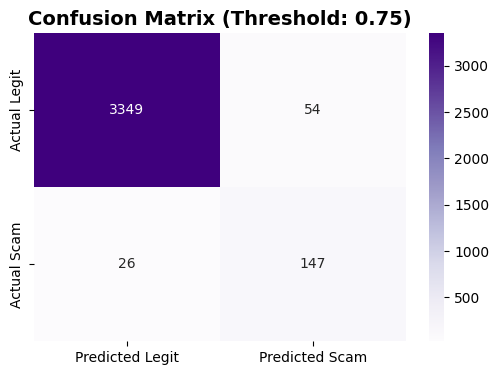


Summary
Caught Scams (True Positives): 147
Missed Scams (False Negatives): 26
False Alarms (False Positives): 54 (Reduced by raising threshold)
Correctly Allowed (True Negatives): 3349


In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Raw probability scores
y_prob_nn = model.predict([X_test_text, X_test_meta]).flatten()

# Model must now be 75% confident before triggering a block, sacrificing a small amount of recall to reduce false alarms.
decision_threshold = 0.75
y_pred_tuned = (y_prob_nn > decision_threshold).astype(int)

print(f"\nClassification (Threshold = {decision_threshold}):")
print(classification_report(y_test, y_pred_tuned, target_names=['Legitimate (0)', 'Scam (1)']))

# Generate the Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Legit', 'Predicted Scam'],
            yticklabels=['Actual Legit', 'Actual Scam'])
plt.title(f'Confusion Matrix (Threshold: {decision_threshold})', fontsize=14, fontweight='bold')
plt.show()

true_neg = cm_tuned[0][0]
false_pos = cm_tuned[0][1]
false_neg = cm_tuned[1][0]
true_pos = cm_tuned[1][1]

print("\nSummary")
print(f"Caught Scams (True Positives): {true_pos}")
print(f"Missed Scams (False Negatives): {false_neg}")
print(f"False Alarms (False Positives): {false_pos} (Reduced by raising threshold)")
print(f"Correctly Allowed (True Negatives): {true_neg}")

In [36]:
import pandas as pd

# Operational thresholds
AUTO_ALLOW_MAX = 0.40
AUTO_BLOCK_MIN = 0.85

# Attach the neural network's raw probabilities back to the original test data
triage_df = df_clean.loc[X_test.index, ['title', 'company_profile', 'description', 'has_company_logo']].copy()
triage_df['fraud_probability'] = y_prob_nn
triage_df['actual_label'] = y_test

# Categorise each post based on the thresholds
def route_post(prob):
    if prob < AUTO_ALLOW_MAX:
        return 'Auto-Allow'
    elif prob >= AUTO_BLOCK_MIN:
        return 'Auto-Block'
    else:
        return 'Manual Review'

triage_df['action_taken'] = triage_df['fraud_probability'].apply(route_post)

# Summarise actions
routing_summary = triage_df['action_taken'].value_counts().reset_index()
routing_summary.columns = ['Action Taken', 'No. of Ads']

print("\nSummary")
display(routing_summary)


Summary


,Action Taken,No. of Ads
0,Auto-Allow,3310
1,Auto-Block,185
2,Manual Review,81
